Notebook Setup & Enhancement Configuration

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import cv2

print("=" * 75)
print("NOTEBOOK 5 — ENHANCEMENT LIBRARY")
print("=" * 75)

PROJECT_ROOT = Path(r"E:\ML_Project")

RESULTS_PATH = (
    PROJECT_ROOT /
    "results"
)
FIGURES_PATH = (
    PROJECT_ROOT /
    "figures"
)
MODELS_PATH = (
    PROJECT_ROOT /
    "models"
)

# Create directories if they do not already exist
RESULTS_PATH.mkdir(
    parents=True,
    exist_ok=True
)

FIGURES_PATH.mkdir(
    parents=True,
    exist_ok=True
)

MODELS_PATH.mkdir(
    parents=True,
    exist_ok=True
)


# Final enhancement actions

ENHANCEMENT_ACTIONS = {
    0: "identity",
    1: "clahe",
    2: "gamma",
    3: "dehazing",
    4: "denoising"
}

print("\nEnhancement Actions")
print("-" * 75)

for action_id, action_name in ENHANCEMENT_ACTIONS.items():
    print(
        f"Action {action_id}: {action_name}"
    )

# Final IQA feature list


FINAL_IQA_FEATURES = [
    "mean_brightness",
    "rms_contrast",
    "laplacian_variance",
    "tenengrad",
    "entropy",
    "dark_pixel_ratio",
    "bright_pixel_ratio",
    "mean_saturation",
    "saturation_std",
    "colorfulness",
    "edge_density",
    "noise_proxy",
    "motion_blur_proxy"
]

print("\nFinal IQA Features")
print("-" * 75)

for i, feature in enumerate(
    FINAL_IQA_FEATURES,
    start=1
):
    print(
        f"{i:2d}. {feature}"
    )

# Environment information


print("\n" + "-" * 75)
print("Environment")
print("-" * 75)

print(
    f"OpenCV version : {cv2.__version__}"
)
print(
    f"NumPy version  : {np.__version__}"
)
print(
    f"Pandas version : {pd.__version__}"
)

print("\n✓ Notebook 5 setup completed successfully.")

NOTEBOOK 5 — ENHANCEMENT LIBRARY

Enhancement Actions
---------------------------------------------------------------------------
Action 0: identity
Action 1: clahe
Action 2: gamma
Action 3: dehazing
Action 4: denoising

Final IQA Features
---------------------------------------------------------------------------
 1. mean_brightness
 2. rms_contrast
 3. laplacian_variance
 4. tenengrad
 5. entropy
 6. dark_pixel_ratio
 7. bright_pixel_ratio
 8. mean_saturation
 9. saturation_std
10. colorfulness
11. edge_density
12. noise_proxy
13. motion_blur_proxy

---------------------------------------------------------------------------
Environment
---------------------------------------------------------------------------
OpenCV version : 4.13.0
NumPy version  : 2.2.6
Pandas version : 2.3.3

✓ Notebook 5 setup completed successfully.


Load Final IQA Dataset & Verify Integrity

In [2]:
print("=" * 75)
print("LOADING FINAL IQA DATASET")
print("=" * 75)

train_iqa = pd.read_csv(
    RESULTS_PATH / "iqa_final_features_train.csv"
)
valid_iqa = pd.read_csv(
    RESULTS_PATH / "iqa_final_features_valid.csv"
)
test_iqa = pd.read_csv(
    RESULTS_PATH / "iqa_final_features_test.csv"
)



print("\nDataset Sizes")
print("-" * 75)
print(
    f"Train : {len(train_iqa):,}"
)
print(
    f"Valid : {len(valid_iqa):,}"
)
print(
    f"Test  : {len(test_iqa):,}"
)
print("\nFinal IQA Feature Verification")
print("-" * 75)

missing_train = [
    feature
    for feature in FINAL_IQA_FEATURES
    if feature not in train_iqa.columns
]

missing_valid = [
    feature
    for feature in FINAL_IQA_FEATURES
    if feature not in valid_iqa.columns
]
missing_test = [
    feature
    for feature in FINAL_IQA_FEATURES
    if feature not in test_iqa.columns
]
print(
    f"Missing train features : {len(missing_train)}"
)
print(
    f"Missing valid features : {len(missing_valid)}"
)
print(
    f"Missing test features  : {len(missing_test)}"
)
print("\nData Integrity")
print("-" * 75)

train_nan = (
    train_iqa[
        FINAL_IQA_FEATURES
    ]
    .isna()
    .sum()
    .sum()
)
valid_nan = (
    valid_iqa[
        FINAL_IQA_FEATURES
    ]
    .isna()
    .sum()
    .sum()
)
test_nan = (
    test_iqa[
        FINAL_IQA_FEATURES
    ]
    .isna()
    .sum()
    .sum()
)

train_inf = np.isinf(
    train_iqa[
        FINAL_IQA_FEATURES
    ].to_numpy()
).sum()

valid_inf = np.isinf(
    valid_iqa[
        FINAL_IQA_FEATURES
    ].to_numpy()
).sum()

test_inf = np.isinf(
    test_iqa[
        FINAL_IQA_FEATURES
    ].to_numpy()
).sum()

print(
    f"Train NaN      : {train_nan}"
)
print(
    f"Valid NaN      : {valid_nan}"
)
print(
    f"Test NaN       : {test_nan}"
)
print(
    f"Train Infinite : {train_inf}"
)
print(
    f"Valid Infinite : {valid_inf}"
)
print(
    f"Test Infinite  : {test_inf}"
)
print("\nSplit Verification")
print("-" * 75)
print(
    "Train splits:",
    train_iqa["split"].unique()
)
print(
    "Valid splits:",
    valid_iqa["split"].unique()
)
print(
    "Test splits:",
    test_iqa["split"].unique()
)


all_features_present = (
    len(missing_train) == 0
    and len(missing_valid) == 0
    and len(missing_test) == 0
)
all_values_valid = (
    train_nan == 0
    and valid_nan == 0
    and test_nan == 0
    and train_inf == 0
    and valid_inf == 0
    and test_inf == 0
)

print("\n" + "=" * 75)

if all_features_present and all_values_valid:
    print("✓ FINAL IQA DATASET PASSED INTEGRITY CHECK")
else:
    print("⚠ DATASET INTEGRITY CHECK REQUIRES ATTENTION")

print("=" * 75)

LOADING FINAL IQA DATASET

Dataset Sizes
---------------------------------------------------------------------------
Train : 70,000
Valid : 10,000
Test  : 20,000

Final IQA Feature Verification
---------------------------------------------------------------------------
Missing train features : 0
Missing valid features : 0
Missing test features  : 0

Data Integrity
---------------------------------------------------------------------------
Train NaN      : 0
Valid NaN      : 0
Test NaN       : 0
Train Infinite : 0
Valid Infinite : 0
Test Infinite  : 0

Split Verification
---------------------------------------------------------------------------
Train splits: ['train']
Valid splits: ['valid']
Test splits: ['test']

✓ FINAL IQA DATASET PASSED INTEGRITY CHECK


Select Representative Images for Enhancement Testing

In [3]:
print("=" * 75)
print("SELECTING REPRESENTATIVE IMAGES")
print("=" * 75)


ENHANCEMENT_TEST_SIZE = 8
enhancement_sample = (
    train_iqa
    .sample(
        n=ENHANCEMENT_TEST_SIZE,
        random_state=42
    )
    .reset_index(drop=True)
)

print(
    f"\nSelected images: "
    f"{len(enhancement_sample)}"
)
print("\nSelected Images")
print("-" * 75)

for i, row in enhancement_sample.iterrows():

    print(
        f"{i + 1}. {row['image_name']}"
    )
    print(
        f"   Path: {row['image_path']}"
    )
    print(
        f"   Brightness : "
        f"{row['mean_brightness']:.3f}"
    )
    print(
        f"   Contrast   : "
        f"{row['rms_contrast']:.3f}"
    )
    print(
        f"   Sharpness  : "
        f"{row['laplacian_variance']:.3f}"
    )
    print(
        f"   Entropy    : "
        f"{row['entropy']:.3f}"
    )
    print(
        f"   Noise      : "
        f"{row['noise_proxy']:.3f}"
    )
    print(
        f"   Motion Blur: "
        f"{row['motion_blur_proxy']:.3f}"
    )
    print()

enhancement_test_images = []
for _, row in enhancement_sample.iterrows():

    image_path = Path(
        row["image_path"]
    )

    image = Image.open(
        image_path
    ).convert("RGB")

    enhancement_test_images.append(
        image
    )
print(
    "✓ All representative images loaded successfully."
)
print(
    f"✓ Ready to test "
    f"{len(enhancement_test_images)} images "
    f"across the 5 enhancement actions."
)

SELECTING REPRESENTATIVE IMAGES

Selected images: 8

Selected Images
---------------------------------------------------------------------------
1. 77229e81-1431e3fd.jpg
   Path: E:\ML_Project\datasets\bdd100k_original_yolo\train\images\77229e81-1431e3fd.jpg
   Brightness : 105.079
   Contrast   : 56.958
   Sharpness  : 507.997
   Entropy    : 7.536
   Noise      : 5.956
   Motion Blur: 0.060

2. 7b511a14-7c952ddf.jpg
   Path: E:\ML_Project\datasets\bdd100k_original_yolo\train\images\7b511a14-7c952ddf.jpg
   Brightness : 129.746
   Contrast   : 64.267
   Sharpness  : 583.612
   Entropy    : 7.631
   Noise      : 5.364
   Motion Blur: 0.192

3. 69c0d941-2c5dbcf0.jpg
   Path: E:\ML_Project\datasets\bdd100k_original_yolo\train\images\69c0d941-2c5dbcf0.jpg
   Brightness : 23.692
   Contrast   : 33.397
   Sharpness  : 488.445
   Entropy    : 5.761
   Noise      : 6.070
   Motion Blur: 0.286

4. 57ca687c-8a31f678.jpg
   Path: E:\ML_Project\datasets\bdd100k_original_yolo\train\images\57ca687c

Identity / No Enhancement

In [4]:
print("=" * 75)
print("ACTION 0 — IDENTITY / NO ENHANCEMENT")
print("=" * 75)

def apply_identity(image):
    """
    Return the input image without applying any enhancement.

    Action ID: 0
    """

    # Return a copy so that downstream operations
    # cannot accidentally modify the original image.
    return image.copy()


print("✓ Identity enhancement function defined.")
print("✓ Action ID: 0")
print("✓ Operation: No enhancement")

ACTION 0 — IDENTITY / NO ENHANCEMENT
✓ Identity enhancement function defined.
✓ Action ID: 0
✓ Operation: No enhancement


CLAHE

In [5]:
print("=" * 75)
print("ACTION 1 — CLAHE")
print("=" * 75)

def apply_clahe(
    image,
    clip_limit=2.0,
    tile_grid_size=(8, 8)
):
    """
    Apply CLAHE to the luminance channel.

    Parameters
    ----------
    image : PIL.Image
        RGB input image.

    clip_limit : float
        CLAHE contrast limiting parameter.

    tile_grid_size : tuple
        Size of the local contextual regions.

    Returns
    -------
    PIL.Image
        Enhanced RGB image.

    Action ID: 1
    """

    # PIL → NumPy
    image_rgb = np.asarray(
        image
    )

    # RGB → LAB
    image_lab = cv2.cvtColor(
        image_rgb,
        cv2.COLOR_RGB2LAB
    )

    # Separate LAB channels
    l_channel, a_channel, b_channel = cv2.split(
        image_lab
    )

    # Create CLAHE operator
    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=tile_grid_size
    )

    # Apply CLAHE only to luminance
    l_enhanced = clahe.apply(
        l_channel
    )

    # Recombine channels
    enhanced_lab = cv2.merge(
        [
            l_enhanced,
            a_channel,
            b_channel
        ]
    )

    # LAB → RGB
    enhanced_rgb = cv2.cvtColor(
        enhanced_lab,
        cv2.COLOR_LAB2RGB
    )

    # NumPy → PIL
    enhanced_image = Image.fromarray(
        enhanced_rgb
    )

    return enhanced_image
    
print("✓ CLAHE function defined.")
print("✓ Action ID: 1")
print("✓ Applied to LAB luminance channel.")
print("✓ Default parameters: clipLimit=2.0, tileGridSize=(8, 8)")

ACTION 1 — CLAHE
✓ CLAHE function defined.
✓ Action ID: 1
✓ Applied to LAB luminance channel.
✓ Default parameters: clipLimit=2.0, tileGridSize=(8, 8)


Gamma Correction

In [6]:
print("=" * 75)
print("ACTION 2 — GAMMA CORRECTION")
print("=" * 75)


def apply_gamma(
    image,
    gamma=0.8
):
    """
    Apply gamma correction to an RGB image.

    gamma < 1:
        Brightens the image.

    gamma > 1:
        Darkens the image.

    Action ID: 2
    """

    # PIL → NumPy
    image_rgb = np.asarray(
        image
    ).astype(
        np.float32
    )

    # Normalize pixel values to [0, 1]
    normalized = (
        image_rgb / 255.0
    )

    # Gamma transformation
    corrected = np.power(
        normalized,
        gamma
    )

    # Convert back to [0, 255]
    corrected = np.clip(
        corrected * 255.0,
        0,
        255
    ).astype(
        np.uint8
    )

    # NumPy → PIL
    enhanced_image = Image.fromarray(
        corrected
    )

    return enhanced_image

print("✓ Gamma correction function defined.")
print("✓ Action ID: 2")
print("✓ Fixed gamma: 0.8")
print("✓ gamma < 1 → image brightening")

ACTION 2 — GAMMA CORRECTION
✓ Gamma correction function defined.
✓ Action ID: 2
✓ Fixed gamma: 0.8
✓ gamma < 1 → image brightening


Dehazing

In [7]:
print("=" * 75)
print("ACTION 3 — DEHAZING")
print("=" * 75)

def apply_dehazing(
    image,
    omega=0.75,
    patch_size=15,
    t_min=0.20
):
    """
    Apply conservative Dark Channel Prior
    based dehazing.

    Action ID: 3
    """
    # PIL → normalized RGB NumPy array
    
    image_rgb = np.asarray(
        image
    ).astype(
        np.float32
    ) / 255.0

    # Dark channel

    min_channel = np.min(
        image_rgb,
        axis=2
    )

    kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (patch_size, patch_size)
    )

    dark_channel = cv2.erode(
        min_channel,
        kernel
    )


    # Atmospheric light estimation

    flat_dark = dark_channel.ravel()

    flat_image = image_rgb.reshape(
        -1,
        3
    )

    num_pixels = len(
        flat_dark
    )

    num_top = max(
        1,
        int(num_pixels * 0.001)
    )

    indices = np.argpartition(
        flat_dark,
        -num_top
    )[-num_top:]

    atmospheric_candidates = (
        flat_image[indices]
    )

    brightness = (
        atmospheric_candidates.sum(
            axis=1
        )
    )

    atmospheric_light = (
        atmospheric_candidates[
            np.argmax(brightness)
        ]
    )


    # Transmission estimation

    normalized_image = (
        image_rgb /
        (
            atmospheric_light[
                None,
                None,
                :
            ] + 1e-6
        )
    )

    normalized_min = np.min(
        normalized_image,
        axis=2
    )

    normalized_min = cv2.erode(
        normalized_min,
        kernel
    )

    transmission = (
        1.0
        - omega * normalized_min
    )

    transmission = np.clip(
        transmission,
        t_min,
        1.0
    )

    # Scene radiance recovery

    transmission_3c = (
        transmission[:, :, None]
    )

    recovered = (
        image_rgb
        - atmospheric_light[
            None,
            None,
            :
        ]
    ) / transmission_3c

    recovered += (
        atmospheric_light[
            None,
            None,
            :
        ]
    )


    # Clip and convert back to PIL

    recovered = np.clip(
        recovered,
        0.0,
        1.0
    )

    recovered = (
        recovered * 255.0
    ).astype(
        np.uint8
    )

    enhanced_image = Image.fromarray(
        recovered
    )

    return enhanced_image

print("✓ Dehazing function defined.")
print("✓ Action ID: 3")
print("✓ Method: Dark Channel Prior")
print("✓ Fixed omega: 0.75")
print("✓ Fixed patch size: 15")
print("✓ Fixed minimum transmission: 0.20")

ACTION 3 — DEHAZING
✓ Dehazing function defined.
✓ Action ID: 3
✓ Method: Dark Channel Prior
✓ Fixed omega: 0.75
✓ Fixed patch size: 15
✓ Fixed minimum transmission: 0.20


Denoising

In [8]:
print("=" * 75)
print("ACTION 4 — DENOISING")
print("=" * 75)

def apply_denoising(
    image,
    h=10,
    h_color=10,
    template_window_size=7,
    search_window_size=21
):
    """
    Apply Non-Local Means denoising to a color image.

    Parameters
    ----------
    image : PIL.Image
        RGB input image.

    h : float
        Filter strength for luminance.

    h_color : float
        Filter strength for color components.

    template_window_size : int
        Size of the template patch.

    search_window_size : int
        Size of the search region.

    Returns
    -------
    PIL.Image
        Denoised RGB image.

    Action ID: 4
    """

    # PIL → NumPy
    image_rgb = np.asarray(
        image
    )

    # OpenCV expects the image in BGR
    image_bgr = cv2.cvtColor(
        image_rgb,
        cv2.COLOR_RGB2BGR
    )

    # Non-Local Means denoising
    denoised_bgr = cv2.fastNlMeansDenoisingColored(
        image_bgr,
        None,
        h,
        h_color,
        template_window_size,
        search_window_size
    )

    # BGR → RGB
    denoised_rgb = cv2.cvtColor(
        denoised_bgr,
        cv2.COLOR_BGR2RGB
    )

    # NumPy → PIL
    enhanced_image = Image.fromarray(
        denoised_rgb
    )

    return enhanced_image


print("✓ Denoising function defined.")
print("✓ Action ID: 4")
print("✓ Method: Non-Local Means")
print("✓ Default h: 10")
print("✓ Default color strength: 10")
print("✓ Template window: 7")
print("✓ Search window: 21")

ACTION 4 — DENOISING
✓ Denoising function defined.
✓ Action ID: 4
✓ Method: Non-Local Means
✓ Default h: 10
✓ Default color strength: 10
✓ Template window: 7
✓ Search window: 21


VISUAL SANITY CHECK — ENHANCEMENT LIBRARY

Testing image:
77229e81-1431e3fd.jpg

Applying all five actions...
✓ Action 0: identity
✓ Action 1: clahe
✓ Action 2: gamma
✓ Action 3: dehazing
✓ Action 4: denoising


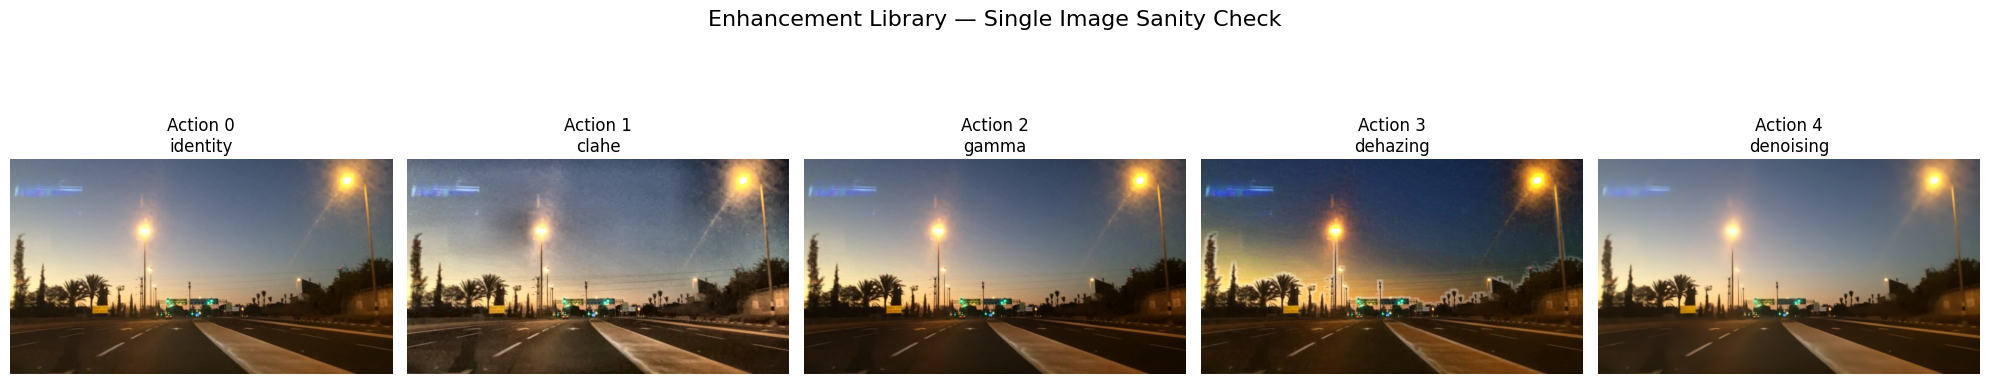


✓ Single-image enhancement test completed.


In [9]:
print("=" * 75)
print("VISUAL SANITY CHECK — ENHANCEMENT LIBRARY")
print("=" * 75)

def apply_enhancement(
    image,
    action_id
):
    """
    Apply one of the five candidate enhancement actions.

    Action 0: Identity
    Action 1: CLAHE
    Action 2: Gamma
    Action 3: Dehazing
    Action 4: Denoising
    """

    if action_id == 0:
        return apply_identity(image)

    elif action_id == 1:
        return apply_clahe(image)

    elif action_id == 2:
        return apply_gamma(
            image,
            gamma=1.2
        )

    elif action_id == 3:
        return apply_dehazing(image)

    elif action_id == 4:
        return apply_denoising(image)

    else:
        raise ValueError(
            f"Unknown action ID: {action_id}"
        )


# Test one image first
test_image = enhancement_test_images[0]

print("\nTesting image:")
print(
    enhancement_sample.loc[0, "image_name"]
)

print("\nApplying all five actions...")

test_results = {}

for action_id in ENHANCEMENT_ACTIONS:

    result = apply_enhancement(
        test_image,
        action_id
    )

    test_results[action_id] = result

    print(
        f"✓ Action {action_id}: "
        f"{ENHANCEMENT_ACTIONS[action_id]}"
    )


# ----------------------------------------------------------
# Display results
# ----------------------------------------------------------

fig, axes = plt.subplots(
    1,
    5,
    figsize=(20, 5)
)

for action_id, ax in zip(
    ENHANCEMENT_ACTIONS,
    axes
):

    ax.imshow(
        test_results[action_id]
    )

    ax.set_title(
        f"Action {action_id}\n"
        f"{ENHANCEMENT_ACTIONS[action_id]}"
    )

    ax.axis("off")


plt.suptitle(
    "Enhancement Library — Single Image Sanity Check",
    fontsize=16
)

plt.tight_layout()

plt.show()


print("\n✓ Single-image enhancement test completed.")

Image Enhancement Validation

8-IMAGE ENHANCEMENT LIBRARY VALIDATION
✓ Image 1/8 processed.
✓ Image 2/8 processed.
✓ Image 3/8 processed.
✓ Image 4/8 processed.
✓ Image 5/8 processed.
✓ Image 6/8 processed.
✓ Image 7/8 processed.
✓ Image 8/8 processed.


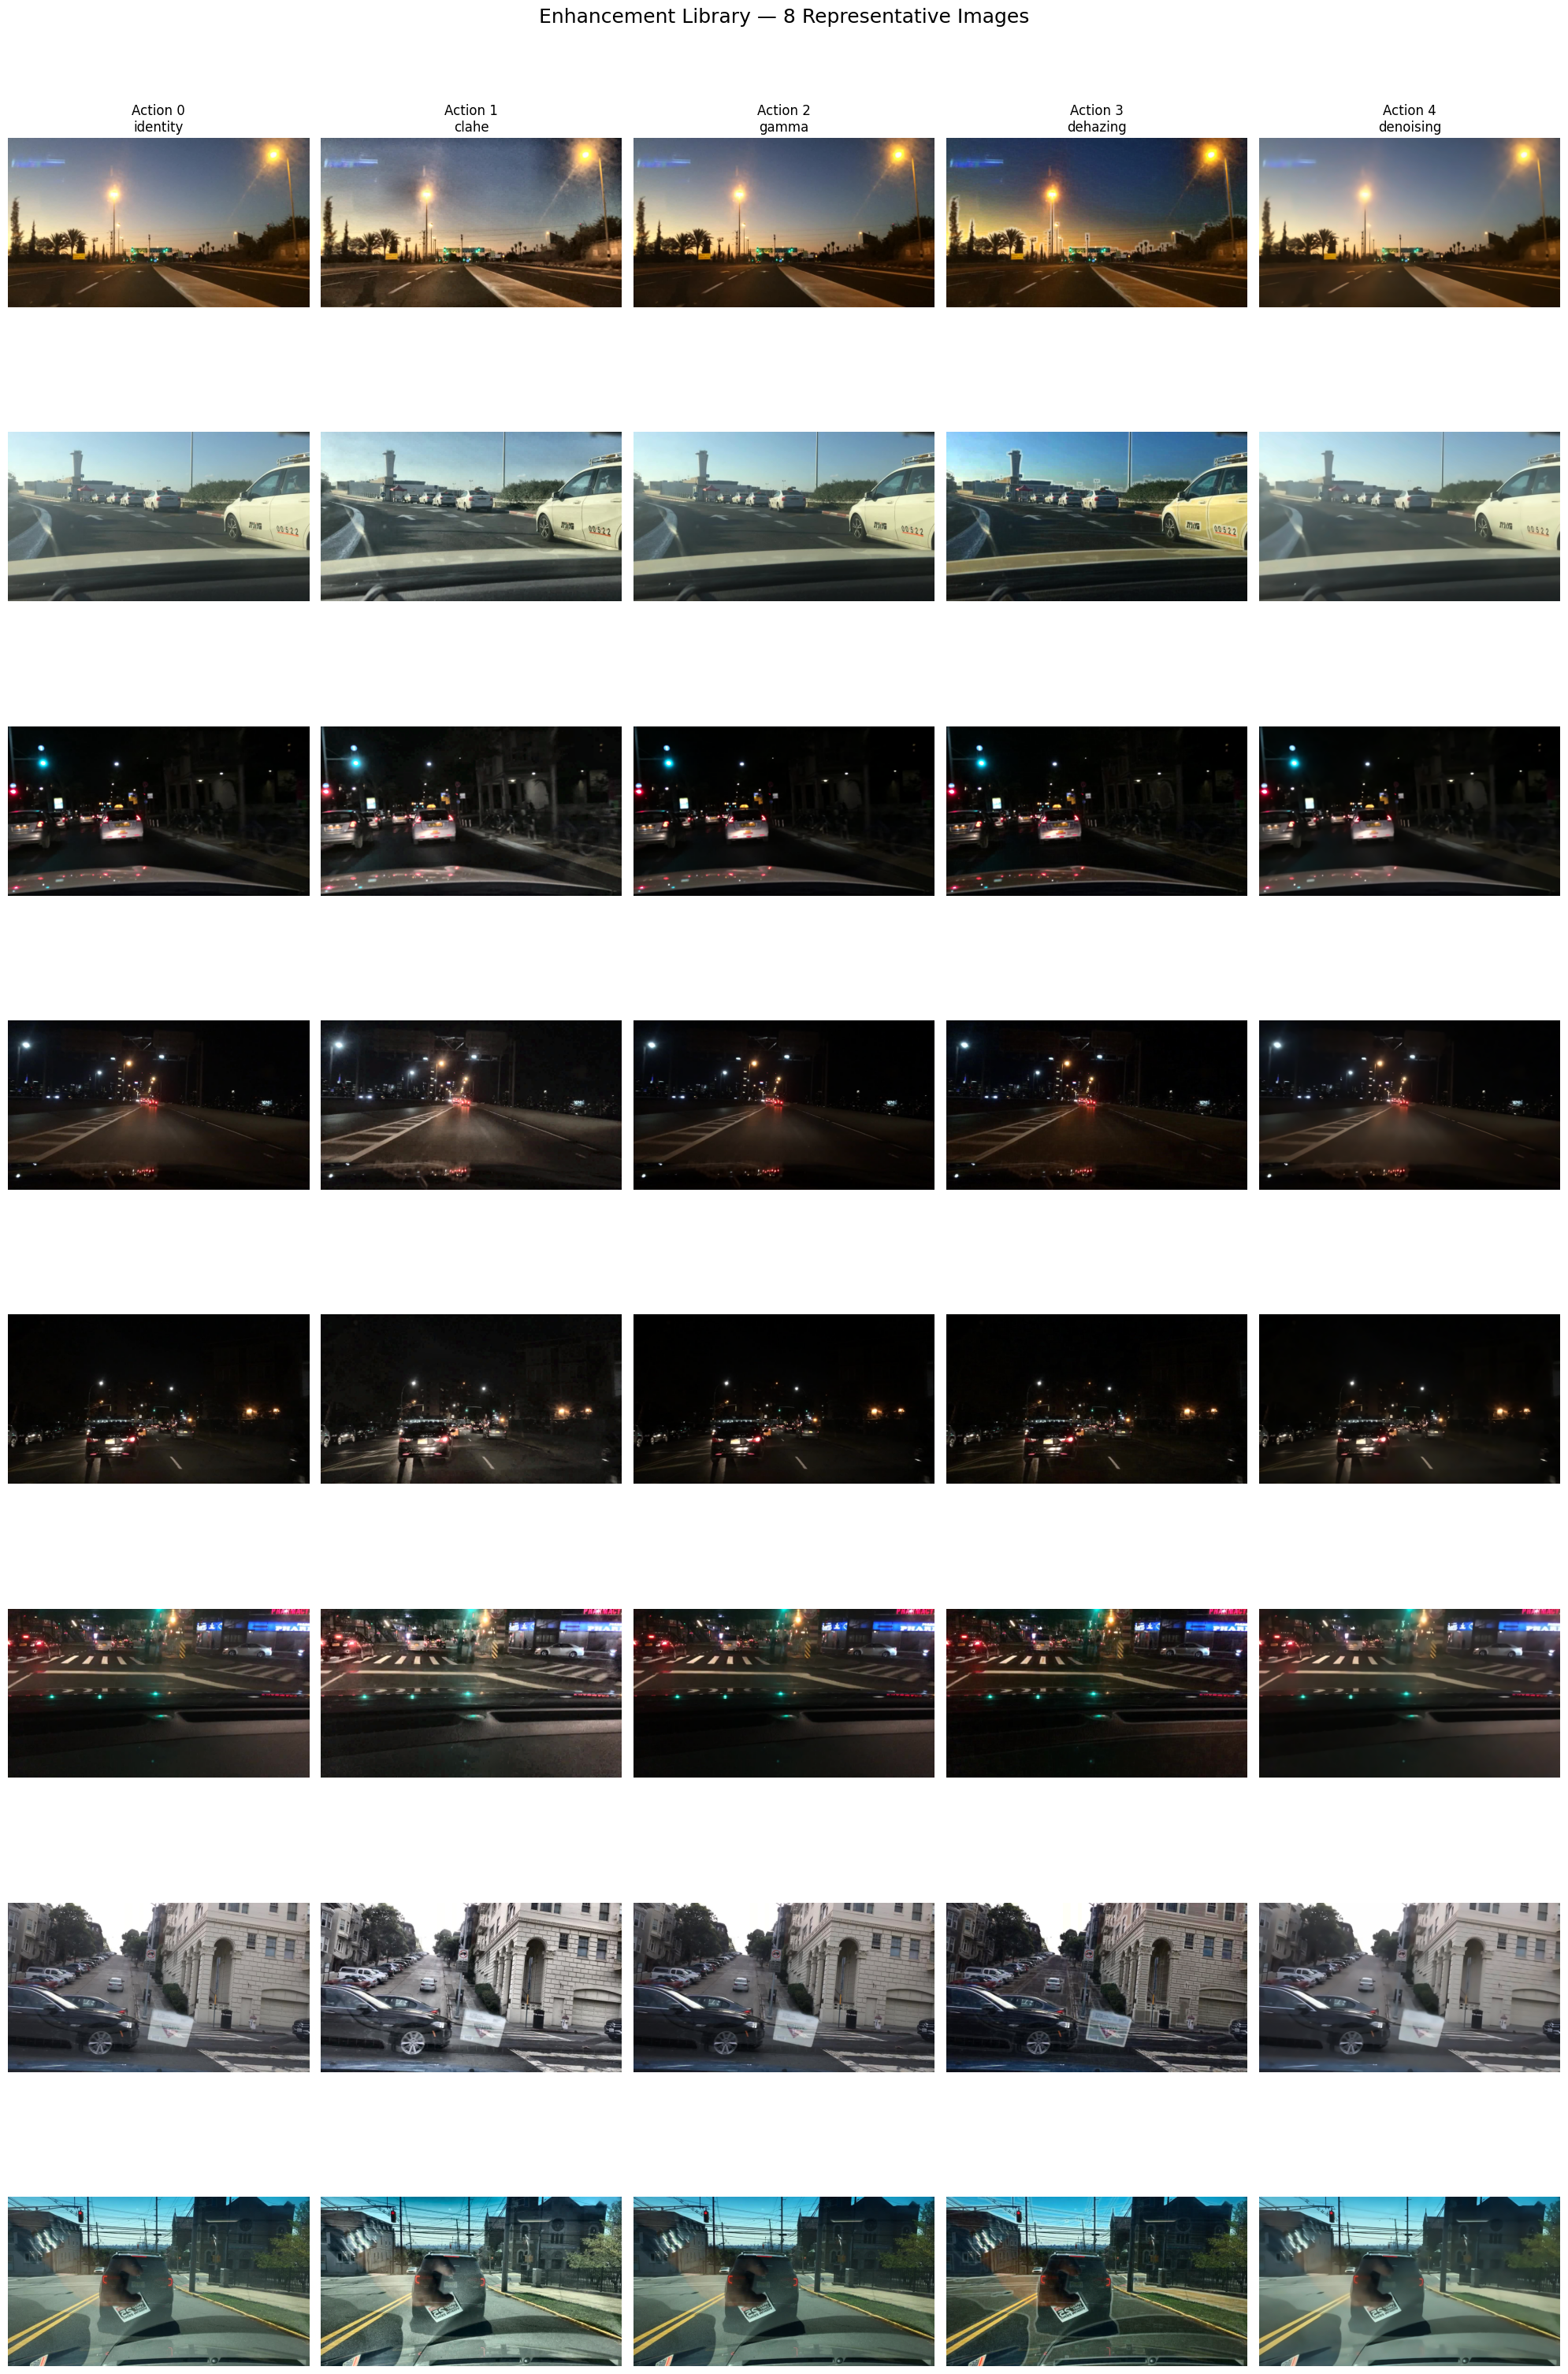


VALIDATION COMPLETED

✓ Images tested      : 8
✓ Actions tested     : 5
✓ Transformations   : 40

✓ Figure saved to:
E:\ML_Project\figures\enhancement_library_8image_validation.png

✓ Original dataset images were not modified.


In [10]:
print("=" * 75)
print("8-IMAGE ENHANCEMENT LIBRARY VALIDATION")
print("=" * 75)

all_enhancement_results = {}

for image_index, image in enumerate(
    enhancement_test_images
):

    image_results = {}

    for action_id in ENHANCEMENT_ACTIONS:
        enhanced_image = apply_enhancement(
            image,
            action_id
        )
        image_results[action_id] = (
            enhanced_image
        )
    all_enhancement_results[
        image_index
    ] = image_results

    print(
        f"✓ Image {image_index + 1}/"
        f"{len(enhancement_test_images)} processed."
    )

num_images = len(
    enhancement_test_images
)
num_actions = len(
    ENHANCEMENT_ACTIONS
)
fig, axes = plt.subplots(
    num_images,
    num_actions,
    figsize=(20, 4 * num_images)
)


for image_index in range(
    num_images
):
    for action_id in ENHANCEMENT_ACTIONS:
        ax = axes[
            image_index,
            action_id
        ]
        ax.imshow(
            all_enhancement_results[
                image_index
            ][action_id]
        )
        ax.axis("off")
        if image_index == 0:

            ax.set_title(
                f"Action {action_id}\n"
                f"{ENHANCEMENT_ACTIONS[action_id]}",
                fontsize=12
            )

for image_index in range(
    num_images
):

    axes[
        image_index,
        0
    ].set_ylabel(
        f"Image {image_index + 1}",
        fontsize=11
    )

fig.suptitle(
    "Enhancement Library — 8 Representative Images",
    fontsize=18
)
plt.tight_layout(
    rect=[
        0,
        0,
        1,
        0.985
    ]
)

visual_check_path = (
    FIGURES_PATH
    / "enhancement_library_8image_validation.png"
)
plt.savefig(
    visual_check_path,
    dpi=200,
    bbox_inches="tight"
)
plt.show()

print("\n" + "=" * 75)
print("VALIDATION COMPLETED")
print("=" * 75)
print(
    f"\n✓ Images tested      : {num_images}"
)
print(
    f"✓ Actions tested     : {num_actions}"
)
print(
    f"✓ Transformations   : "
    f"{num_images * num_actions}"
)
print(
    "\n✓ Figure saved to:"
)
print(
    visual_check_path
)
print(
    "\n✓ Original dataset images were not modified."
)

Save Final Enhancement Configuration

In [11]:
print("=" * 75)
print("FINAL ENHANCEMENT LIBRARY CONFIGURATION")
print("=" * 75)


enhancement_config = pd.DataFrame([
    {
        "action_id": 0,
        "action_name": "identity",
        "method": "No enhancement",
        "parameters": "None"
    },
    {
        "action_id": 1,
        "action_name": "clahe",
        "method": "CLAHE on LAB luminance channel",
        "parameters": "clipLimit=2.0; tileGridSize=(8,8)"
    },
    {
        "action_id": 2,
        "action_name": "gamma",
        "method": "Gamma correction",
        "parameters": "gamma=0.8"
    },
    {
        "action_id": 3,
        "action_name": "dehazing",
        "method": "Dark Channel Prior",
        "parameters": "omega=0.75; patch_size=15; t_min=0.20"
    },
    {
        "action_id": 4,
        "action_name": "denoising",
        "method": "Non-Local Means",
        "parameters": (
            "h=10; h_color=10; "
            "template_window_size=7; "
            "search_window_size=21"
        )
    }
])


config_path = (
    RESULTS_PATH /
    "enhancement_library_config.csv"
)


enhancement_config.to_csv(
    config_path,
    index=False
)


print("\nFinal Frozen Actions")
print("-" * 75)

print(
    enhancement_config.to_string(
        index=False
    )
)


print("\n" + "-" * 75)

print(
    f"✓ Configuration saved to:\n"
    f"{config_path}"
)

print(
    "\n✓ Enhancement library is now FROZEN."
)

print(
    "✓ Notebook 5 is COMPLETE."
)

FINAL ENHANCEMENT LIBRARY CONFIGURATION

Final Frozen Actions
---------------------------------------------------------------------------
 action_id action_name                         method                                                      parameters
         0    identity                 No enhancement                                                            None
         1       clahe CLAHE on LAB luminance channel                               clipLimit=2.0; tileGridSize=(8,8)
         2       gamma               Gamma correction                                                       gamma=0.8
         3    dehazing             Dark Channel Prior                           omega=0.75; patch_size=15; t_min=0.20
         4   denoising                Non-Local Means h=10; h_color=10; template_window_size=7; search_window_size=21

---------------------------------------------------------------------------
✓ Configuration saved to:
E:\ML_Project\results\enhancement_library_config.cs